<a href="https://colab.research.google.com/github/heisenberg304/aprendiendo-ml-cloud/blob/semana-5/dia4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_68941/1081301489.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_68941/1081301489.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

matrix -> [[92 13]
 [22 52]]
accuracy -> 0.8044692737430168
precision -> 0.8
recall -> 0.7027027027027027
f1 score -> 0.7482014388489209
Importancia = [0.40311565 0.15560565 0.13944548 0.21360625 0.00589939 0.
 0.0096671  0.07266047]
Profundidad del arbol = 10
Plot = [Text(0.4918176775147929, 0.9545454545454546, 'x[0] <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]'), Text(0.1722448224852071, 0.8636363636363636, 'x[1] <= 6.5\ngini = 0.303\nsamples = 467\nvalue = [380, 87]'), Text(0.33203125, 0.9090909090909092, 'True  '), Text(0.023668639053254437, 0.7727272727272727, 'x[7] <= 3.5\ngini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]'), Text(0.011834319526627219, 0.6818181818181818, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'), Text(0.03550295857988166, 0.6818181818181818, 'x[7] <= 5.5\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'), Text(0.023668639053254437, 0.5909090909090909, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'), Text(0.047337278106508875, 0.5909090909090909, 'x[7] <= 6.5\ngi

,Is_female,Age,Pclass,Fare,C,Q,S,Relatives
0,0,22.0,3,7.2500,False,False,True,1
1,1,38.0,1,71.2833,True,False,False,1


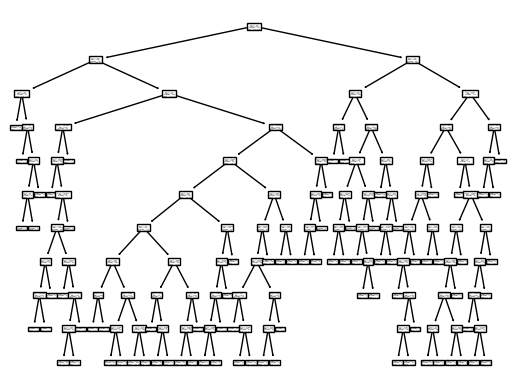

In [1]:
#importar librerias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.tree import plot_tree, export_graphviz
#CARGAR DATOS
data = pd.read_csv("/content/drive/MyDrive/data_csv/titanic.csv")


#Manipular datos
#Aplicar mediana para rellenar
data["Age"].fillna(data["Age"].median(), inplace=True)
#Aplicar moda para rellenar
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)
#nuevas features
data["Is_female"] = data["Sex"].map({"female": 1, "male": 0}) #En el contexto del titanic las prioridad era salvar a las mujeres
data["Relatives"] = data["SibSp"] + data["Parch"]
#Encoding para embarked
embarked = pd.get_dummies(data["Embarked"])
#sex = pd.get_dummies(data["Sex"])                 #otra opcion
#unir las nuevas filas al dataframe principal
data = pd.concat([data, embarked], axis=1)  #pegar dos dataframes uno al lado del otro
#data = pd.concat([data, embarked, sex], axis=1)   #otra opcion
#eliminar linea sobrantes:
data = data.drop(["Sex", "PassengerId", "Name", "Ticket", "Cabin", "Embarked"], axis=1)  #para eliminar columnas


#Crear x and y
x = data[["Is_female", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]] #quitando sibsp y parch el modelo mejora
#x = data[["female", "male", "Age", "Pclass", "Fare", "C", "Q",	"S", "Relatives"]]  #otra opcion
y = data["Survived"]
#Separar dataset en train y test
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 42,
    test_size = 0.2
)


#crear modelo
model = DecisionTreeClassifier(max_depth=10)
#entrenar el modelo
model.fit(x_train, y_train)
#testear modelo
pred = model.predict(x_test)
#profundidad del Tree
depth = model.tree_.max_depth
#Importancia de cada feature
importances = model.feature_importances_
#otros atributos
plot = plot_tree(model)
graphviz = export_graphviz(model)


#metricas
matrix = confusion_matrix(y_test, pred)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
#print de metricas
print(f"matrix -> {matrix}")
print(f"accuracy -> {accuracy}")
print(f"precision -> {precision}")
print(f"recall -> {recall}")
print(f"f1 score -> {f1}")
print(f"Importancia = {importances}")
print(f"Profundidad del arbol = {depth}") #Este valor representa hasta dónde creció el modelo cuando no se limitó su complejidad, lo que suele indicar un escenario de sobreajuste.
print(f"Plot = {plot}")
print(f"Graphviz = {graphviz}")

x.head(2)

